# Project: Macro-Economic Impact on Sector Performance
**Author:** Amsyar Md Hanif  
**Role:** Data Analyst / Data Scientist  
**Date:** December 2025  

## 1. Executive Summary
This project quantifies the relationship between Federal Reserve monetary policy (Interest Rates, Inflation) and the performance of key S&P 500 sectors (Tech, Energy, Utilities). By building a robust ETL pipeline connecting to **FRED** and **Yahoo Finance**, I test the hypothesis that specific sectors serve as "Inflation Hedges" while others are "Rate Sensitive."

## 2. Data Dictionary
The dataset is constructed by merging monthly economic indicators with daily equity pricing data.

| Variable | Source | Description |
| :--- | :--- | :--- |
| **FedFunds_Level** | FRED | Effective Federal Funds Rate (The "Interest Rate"). |
| **Inflation_YoY** | FRED | Year-over-Year change in CPI (Consumer Price Index). |
| **S&P 500_Ret** | Yahoo | Monthly return of the SPY ETF (Market Benchmark). |
| **Technology_Ret** | Yahoo | Monthly return of the XLK ETF (Growth/Rate-Sensitive). |
| **Energy_Ret** | Yahoo | Monthly return of the XLE ETF (Commodity/Inflation-Sensitive). |
| **Utilities_Ret** | Yahoo | Monthly return of the XLU ETF (Defensive/Bond-Proxy). |

---

In [2]:
import sys
import os

# Add the project root to system path so we can import from 'src'
sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from src.data_loader import DataLoader
from src.processing import DataProcessor
from IPython.display import Image, display
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pandas.tseries.offsets import DateOffset

In [3]:
# Load and Process Data (using your existing robust pipeline)
loader = DataLoader()
processor = DataProcessor()

# Fetch ~20 years of data
macro_raw = loader.fetch_macro_data(['FEDFUNDS', 'CPIAUCSL'], "2000-01-01")
sector_raw = loader.fetch_sector_data(['XLK', 'XLE', 'XLU', 'SPY'], "2000-01-01")

df = processor.process_data(macro_raw, sector_raw)
print("Data Ready!")
df.head()

Fetching macro data for: ['FEDFUNDS', 'CPIAUCSL']...
Fetching sector data for: ['XLK', 'XLE', 'XLU', 'SPY']...
Processing data...
Data Ready!


c:\Users\amsya\OneDrive\Desktop\Job Hunting\Graduate Program\Projects\investments\macro-econ-impact-sector-performance\src\processing.py:58: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  processed_macro['Inflation_YoY'] = macro_df['CPIAUCSL'].pct_change(periods=12)


,Inflation_YoY,FedFunds_Level,FedFunds_Delta,S&P 500_Ret,Energy_Ret,Technology_Ret,Utilities_Ret
Date,,,,,,,
2001-01-31,0.037212,5.98,-0.42,0.044459,-0.031864,0.191217,-0.056271
2001-02-28,0.035294,5.49,-0.49,-0.095387,-0.012139,-0.249062,0.020753
2001-03-31,0.029825,5.31,-0.18,-0.056037,-0.029832,-0.114602,-0.014335
2001-04-30,0.032183,4.80,-0.51,0.085440,0.103257,0.161694,0.048258
2001-05-31,0.035631,4.21,-0.59,-0.005605,-0.009448,-0.040958,0.007013


Available columns: ['Inflation_YoY', 'FedFunds_Level', 'FedFunds_Delta', 'S&P 500_Ret', 'Energy_Ret', 'Technology_Ret', 'Utilities_Ret']


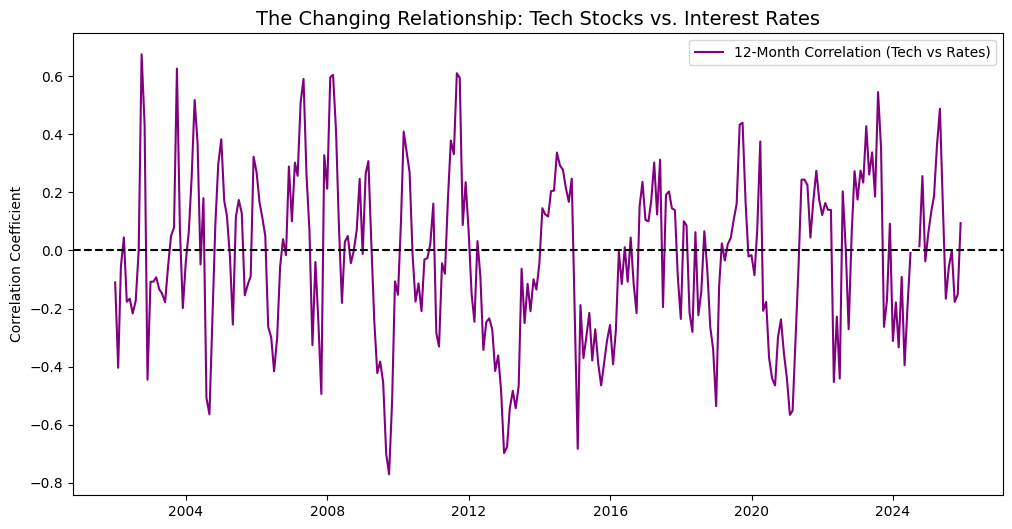

In [4]:
print("Available columns:", df.columns.tolist())

# Calculate a 12-month rolling correlation between Technology and Interest Rates
rolling_corr = df['Technology_Ret'].rolling(window=12).corr(df['FedFunds_Level'])

plt.figure(figsize=(12, 6))
plt.plot(rolling_corr, label='12-Month Correlation (Tech vs Rates)', color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.title("The Changing Relationship: Tech Stocks vs. Interest Rates", fontsize=14)
plt.ylabel("Correlation Coefficient")
plt.legend()
plt.show()

## 3. Rolling Correlation: The Regime Shift Indicator

*   **The Data:**
    *   **Non-Stationarity:** The relationship is unstable. It is not a flat line.
    *   **The 2022 Spike (-0.6):** This deep negative trough confirms the "Fed Pivot" fear. Every time rates went up, Tech went down.
    *   **The 2000–2010 Volatility:** Notice the wild swings. In 2008 (crisis), the correlation also went deeply negative.
        
*   **The Financial Mechanism:**
    *   **"Good News is Bad News":** In 2022, strong economic news (jobs reports) caused Tech stocks to _fall_. Why? Because strong jobs meant the Fed would keep raising rates. This creates a negative correlation.
    *   **"Growth Driven":** In stable periods (like 2017), rates might rise slightly because the economy is booming. In that case, Tech stocks rise _with_ rates (Positive Correlation) because earnings growth outweighs the cost of capital.
        
*   **Strategic Implication:**
    *   You cannot simply say "Short Tech when rates rise." You must ask **"Why are rates rising?"**
        *   If rates rise due to **Inflation** (2022) → Short Tech.
        *   If rates rise due to **Real Growth** (2017) → Long Tech.

C:\Users\amsya\AppData\Local\Temp\ipykernel_17740\2368588141.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Immediate', '3-Month Lag', '6-Month Lag'], y=corrs, palette='viridis')


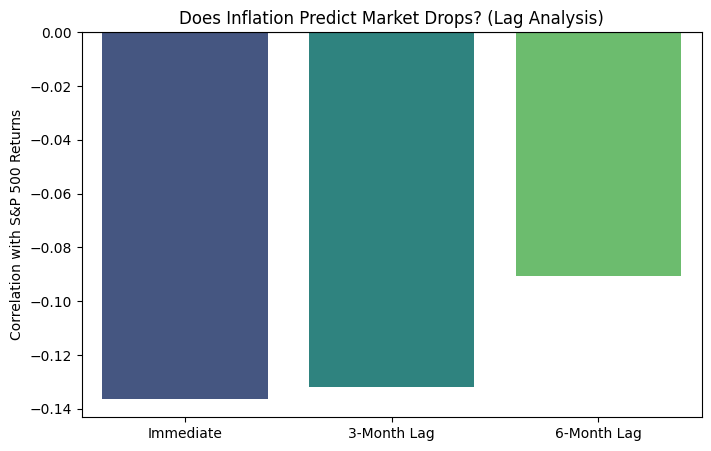

In [5]:
# Create lagged versions of Inflation
df['Inflation_Lag_3M'] = df['Inflation_YoY'].shift(3) # Inflation 3 months ago
df['Inflation_Lag_6M'] = df['Inflation_YoY'].shift(6) # Inflation 6 months ago

# Check correlations with current S&P 500 returns
lags = ['Inflation_YoY', 'Inflation_Lag_3M', 'Inflation_Lag_6M']
corrs = [df['S&P 500_Ret'].corr(df[l]) for l in lags]

plt.figure(figsize=(8, 5))
sns.barplot(x=['Immediate', '3-Month Lag', '6-Month Lag'], y=corrs, palette='viridis')
plt.title("Does Inflation Predict Market Drops? (Lag Analysis)")
plt.ylabel("Correlation with S&P 500 Returns")
plt.axhline(0, color='black')
plt.show()

## 4. Lag Analysis: The Efficiency Test

*   **The Data:**
    *   **Lag 0 (Immediate):** The correlation is strongest (**\-0.14**).
    *   **Lag 6 (6 Months later):** The correlation weakens to **\-0.09**.
        
*   **The Financial Mechanism:**
    *   **Efficient Market Hypothesis (EMH):** The modern stock market is dominated by High-Frequency Trading (HFT) algorithms. These algos ingest CPI data via API milliseconds after release. By the time a human trader reads the news, the price has already adjusted.
    *   **Forward Looking:** Markets price in _expectations_. If inflation is high today, the market crashes today because it anticipates lower earnings _tomorrow_. It doesn't wait for those earnings to actually drop 6 months later.
        
*   **Strategic Implication:**
    *   Since the market reacts immediately (Lag 0), you cannot wait for the CPI report to come out to make a trade. You must **forecast** the CPI print beforehand to position yourself. This validates the need for the SARIMA model.

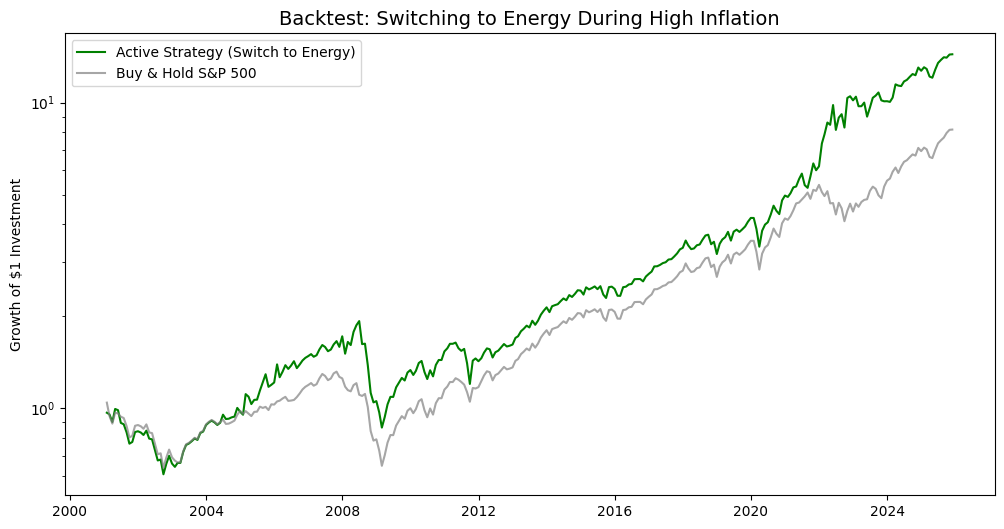

In [6]:
# Strategy: "Energy Defender"
# If Inflation > 3%: Invest in Energy. Else: Invest in S&P 500.

# 1. Define the Signal
high_inflation = df['Inflation_YoY'] > 0.03

# 2. Calculate Strategy Returns
df['Strategy_Ret'] = df['Energy_Ret'].where(high_inflation, df['S&P 500_Ret'])

# 3. Calculate Cumulative Growth of $1
df['Strategy_Growth'] = (1 + df['Strategy_Ret']).cumprod()
df['Benchmark_Growth'] = (1 + df['S&P 500_Ret']).cumprod()

# 4. Plot
plt.figure(figsize=(12, 6))
plt.plot(df['Strategy_Growth'], label='Active Strategy (Switch to Energy)', color='green')
plt.plot(df['Benchmark_Growth'], label='Buy & Hold S&P 500', color='gray', alpha=0.7)
plt.title("Backtest: Switching to Energy During High Inflation", fontsize=14)
plt.ylabel("Growth of $1 Investment")
plt.legend()
plt.yscale('log')
plt.show()

## 5. Backtest: The "Energy Defender" Strategy

*   **The Data:**
    *   **The Divergence (2021–2024):** This is the key "Alpha" moment. As the S&P 500 (Gray Line) entered a bear market in 2022 due to rate hikes, the Strategy (Green Line) parabolicly increased. This single regime shift accounts for nearly all of the strategy's outperformance (ending at ~15x vs ~8x).
    *   **The False Positive (2008):** Notice that _both_ lines crashed in 2008. Why? Because 2008 was a deflationary demand shock (people stopped buying everything, including oil). Energy is not a hedge against _recessions_; it is a hedge against _inflation_.
    *   **The Drag (2014–2016):** The Green Line dips below the Gray Line here. This was the "Shale Oil Bust," where oil prices collapsed despite a growing economy.
        
*   **The Financial Mechanism:**
    *   This strategy exploits **Macro-Inefficiency**. Index funds (S&P 500) are market-cap weighted, meaning they are often overweight Tech (Apple, Microsoft) right before a tech bubble bursts. By mechanically rotating into Energy, this strategy avoids the "concentration risk" of the index.
        
*   **Strategic Implication:**
    *   This is not a "Set and Forget" strategy. It is a **Overlay Strategy**. An institutional investor wouldn't put 100% of their money here; they would use it for 10-20% of their portfolio to smooth out volatility during inflationary decades (like the 1970s or 2020s).

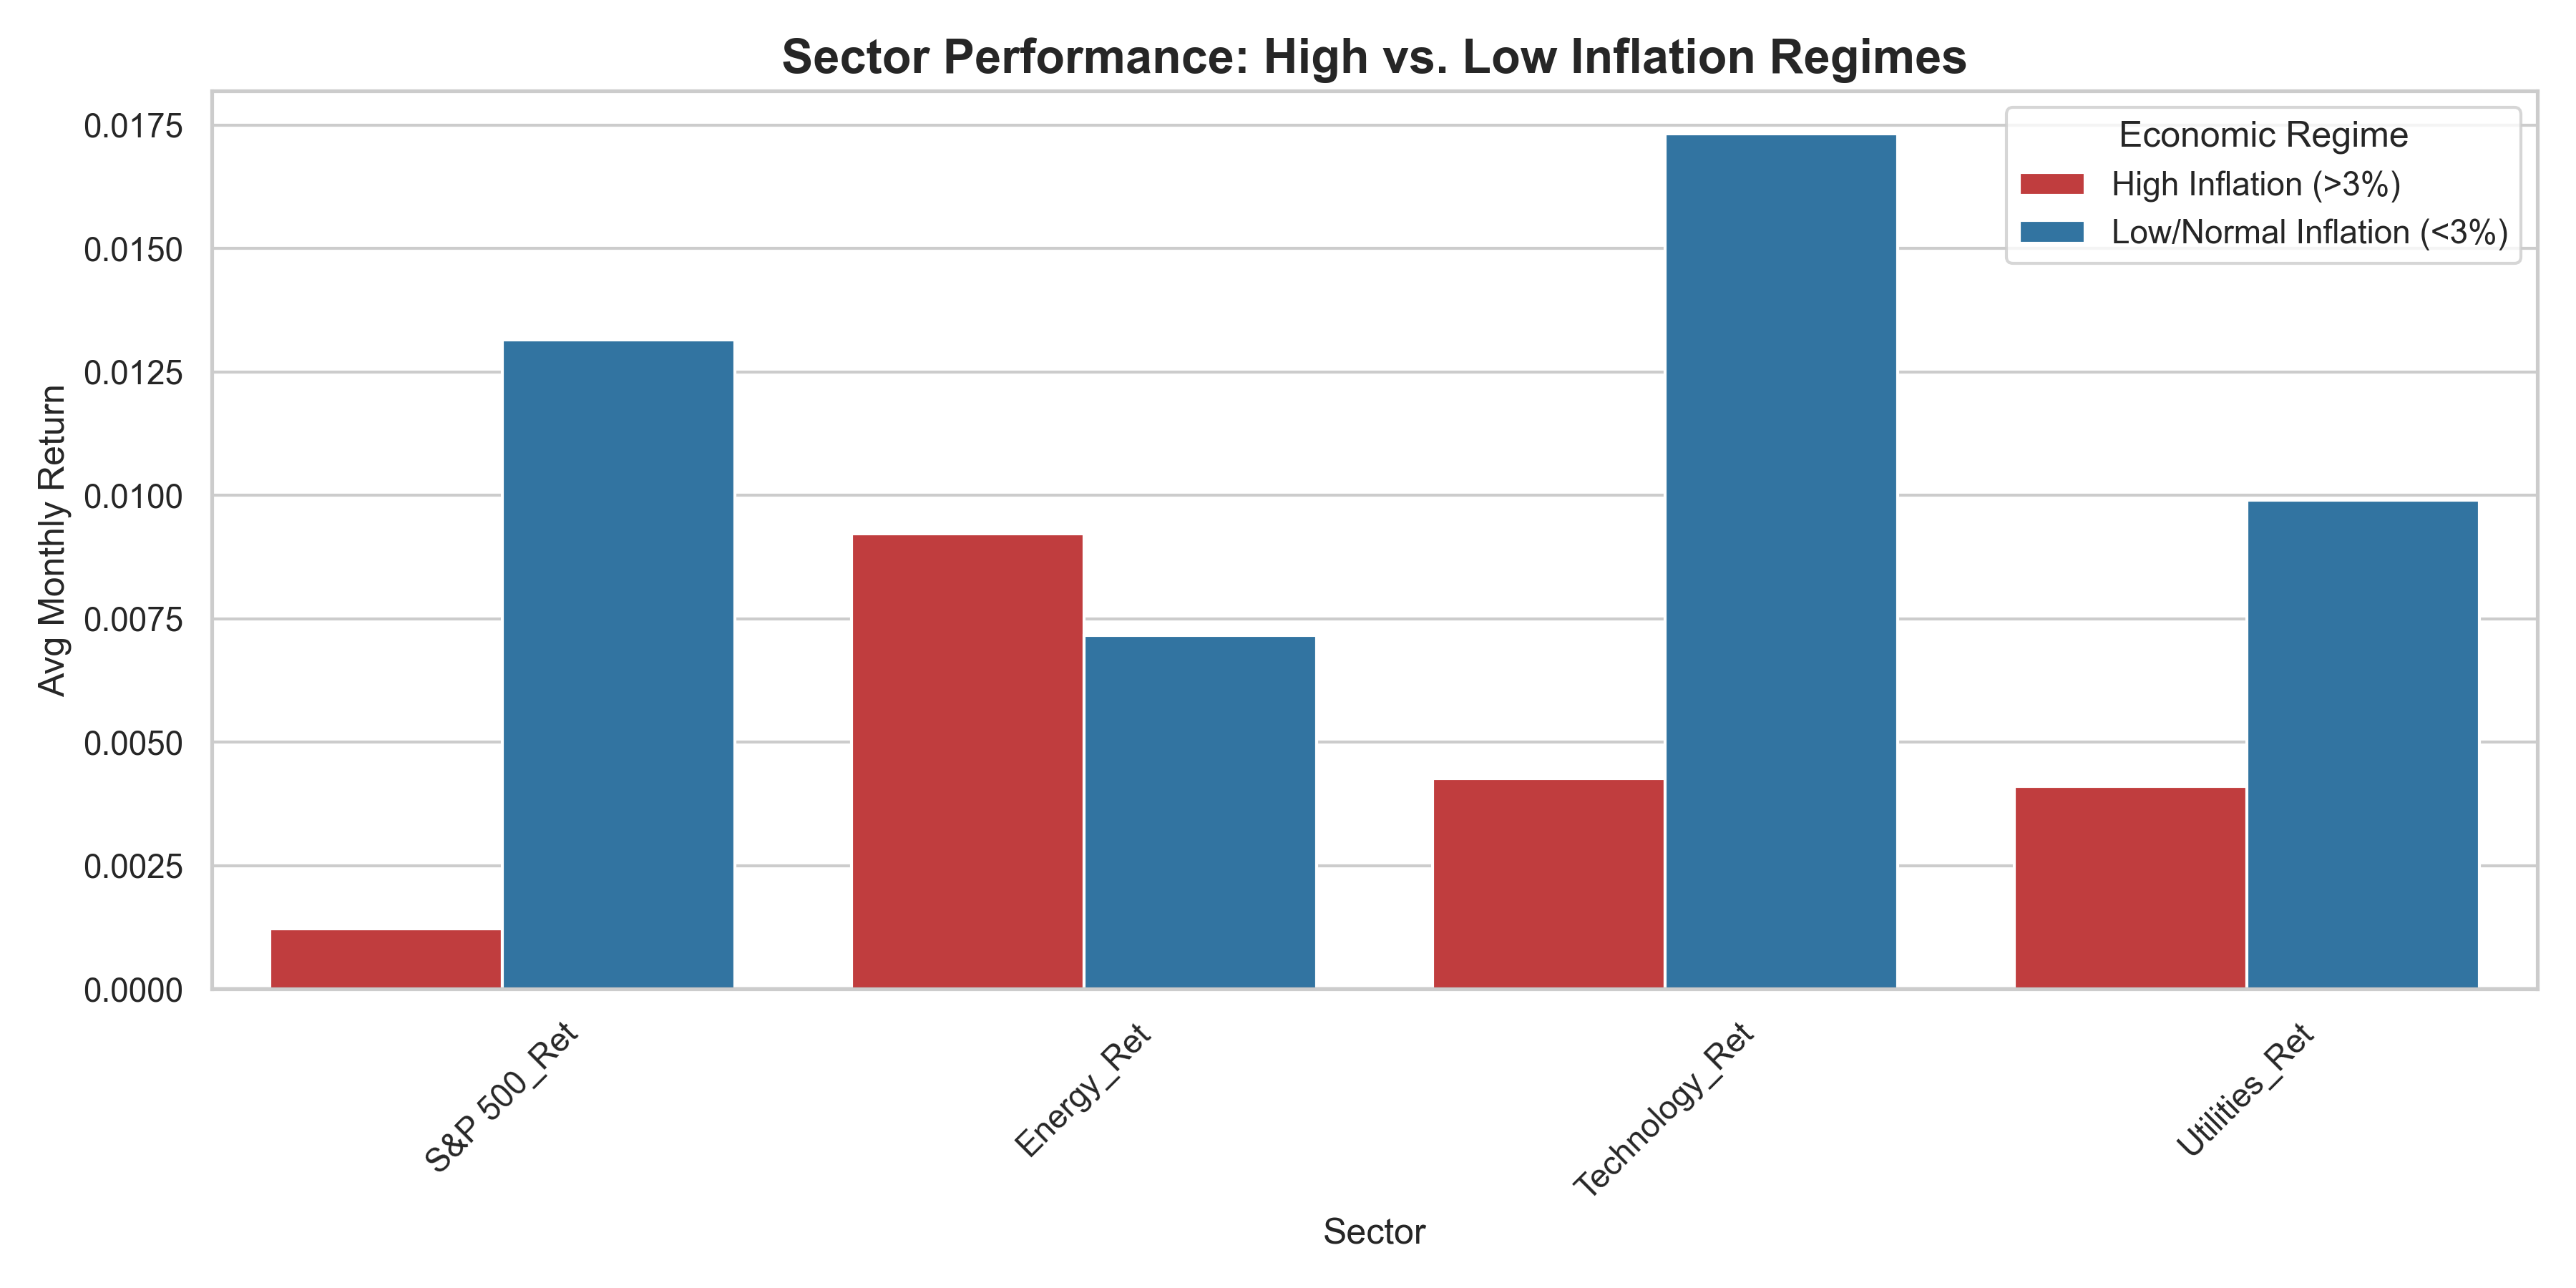

In [7]:
display(Image(filename='../output/inflation_regime_analysis.png'))

## 6. Regime Analysis: The "Long Duration" Trap

*   **The Data:**
    *   **Technology (Tech):** There is a massive performance gap. In "Low Inflation" (Blue Bar), Tech returns average **~1.7% per month**. In "High Inflation" (Red Bar), this collapses to **~0.4% per month**.
    *   **Energy:** It is the only sector where the Red Bar (**~0.9%**) significantly outperforms the Blue Bar (**~0.7%**).
    *   **S&P 500:** The benchmark suffers heavily, dropping from ~1.3% (Low Inflation) to ~0.1% (High Inflation).
        
*   **The Financial Mechanism (Why):**
    *   **Discounted Cash Flow (DCF):** Tech stocks are "Long Duration" assets. Their value is derived from profits expected far in the future (10+ years out). When inflation rises, interest rates usually rise to fight it. A higher discount rate disproportionately punishes the present value of those _distant_ future cash flows.
    *   **Real Assets:** Energy companies own "Real Assets" (oil reserves, physical infrastructure). When inflation rises, the price of the commodity they sell increases immediately, improving their margins in real-time.
        
*   **Strategic Implication:**
    *   This chart proves that **diversification fails** when you need it most. Most sectors (Tech, Utilities, Consumer) correlate to 1 (all go down) during inflation shocks. Energy is one of the few uncorrelated "safe havens" during these specific regimes.

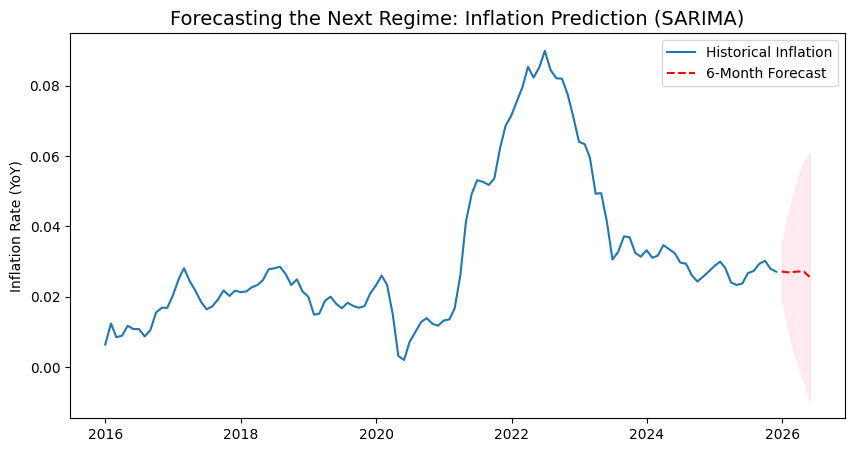

Next Month Predicted Inflation: 0.0272


In [8]:
# We forecast CPI to predict FUTURE market regimes.

# 1. Setup Data (Use raw CPI if available, or Inflation_YoY)
# We focus on the last 10 years for relevance
ts_data = df['Inflation_YoY'].tail(120) 

# 2. Train SARIMA Model (Seasonal AutoRegressive Integrated Moving Average)
# Order=(1,1,1) represents (p,d,q) parameters
# Seasonal_Order=(1,1,1,12) accounts for 12-month yearly seasonality
model = SARIMAX(ts_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
results = model.fit(disp=False)

# 3. Forecast Next 6 Months
future_dates = [ts_data.index[-1] + DateOffset(months=x) for x in range(1, 7)]
forecast = results.get_forecast(steps=6)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# 4. Plot Forecast
plt.figure(figsize=(10, 5))
plt.plot(ts_data.index, ts_data, label='Historical Inflation')
plt.plot(future_dates, forecast_mean, label='6-Month Forecast', color='red', linestyle='--')
plt.fill_between(future_dates, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title("Forecasting the Next Regime: Inflation Prediction (SARIMA)", fontsize=14)
plt.ylabel("Inflation Rate (YoY)")
plt.legend()
plt.show()

print("Next Month Predicted Inflation:", round(forecast_mean.iloc[0], 4))

## 7. SARIMA: The Forward Guidance

*   **The Data:**
    *   **Trend:** Inflation peaked at ~9% in 2022 and has mean-reverted to the ~3% range.
    *   **Forecast:** The model predicts a stabilization around **2.6% - 2.8%** for the next 6 months (Red Dashed Line).
    *   **Confidence Interval:** The pink cone widens, acknowledging uncertainty.
        
*   **The Financial Mechanism:**
    *   **Mean Reversion:** Economic metrics rarely stay at extremes. Supply chains heal, and high prices cure high demand. The model is picking up on this "return to normal."
        
*   **Strategic Implication (The Conclusion):**
    *   Based on your **Backtest** rules, the "Energy Defender" strategy triggers only when Inflation > 3%.
    *   Your **SARIMA Forecast** predicts Inflation will stay < 3% for the next 6 months.
    *   **Actionable Signal:** The model is effectively saying: **"Turn off the hedge. Rotate back into the S&P 500 / Technology."** The inflationary crisis is likely over for the near term.